In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.13.0+cpu


In [2]:
torch.manual_seed(42)

In [3]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("cleaned_global_ecommerce_sales.csv")
target = "Order_Status"
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features aur Target
X = df.drop(columns=[target]).values
y = df[target].values

# Convert to Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print(X_tensor.shape)
print(y_tensor.shape)

C:\Users\cc\AppData\Local\Temp\ipykernel_112\2252452116.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


torch.Size([10000, 25])
torch.Size([10000])


In [4]:
from torch.utils.data import TensorDataset

# Create TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)

print("Dataset Size:", len(dataset))

Dataset Size: 10000


In [5]:
from torch.utils.data import random_split

# Split Dataset (80% Train, 20% Validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))

Train Size: 8000
Validation Size: 2000


## DATA LOADER

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 125
Validation Batches: 32


In [7]:
# Get input and output size from DataLoader

sample_X, sample_y = next(iter(train_loader))

input_size = sample_X.shape[1]
output_size = len(torch.unique(sample_y))

print("Input Size:", input_size)
print("Output Size:", output_size)

Input Size: 25
Output Size: 4


## Adam Optimizer

In [8]:
import torch
import torch.nn as nn

class RegularizedMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RegularizedMLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:
# Model Parameters
input_size = X_tensor.shape[1]
hidden_size = 64
output_size = len(torch.unique(y_tensor))

# Create Regularized Model
regularized_model = RegularizedMLP(
    input_size,
    hidden_size,
    output_size
)

print(regularized_model)

RegularizedMLP(
  (fc1): Linear(in_features=25, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [10]:
import torch.nn as nn
import torch.optim as optim

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer (Daily Drop Day 13)
optimizer = optim.Adam(
    regularized_model.parameters(),
    lr=0.001
)

print("Criterion and Optimizer Created Successfully!")

Criterion and Optimizer Created Successfully!


## Mini Batch Traning Loop(30 Epochs)

In [11]:
# Number of Epochs
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---------------- TRAINING ----------------
    regularized_model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = regularized_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---------------- VALIDATION ----------------
    regularized_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = regularized_model(inputs)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

Epoch [1/30] | Train Loss: 1.1484 | Validation Loss: 1.1077
Epoch [2/30] | Train Loss: 1.0964 | Validation Loss: 1.1024
Epoch [3/30] | Train Loss: 1.0837 | Validation Loss: 1.0963
Epoch [4/30] | Train Loss: 1.0742 | Validation Loss: 1.0924
Epoch [5/30] | Train Loss: 1.0699 | Validation Loss: 1.0931
Epoch [6/30] | Train Loss: 1.0695 | Validation Loss: 1.0872
Epoch [7/30] | Train Loss: 1.0648 | Validation Loss: 1.0854
Epoch [8/30] | Train Loss: 1.0668 | Validation Loss: 1.0829
Epoch [9/30] | Train Loss: 1.0610 | Validation Loss: 1.0793
Epoch [10/30] | Train Loss: 1.0589 | Validation Loss: 1.0804
Epoch [11/30] | Train Loss: 1.0596 | Validation Loss: 1.0807
Epoch [12/30] | Train Loss: 1.0569 | Validation Loss: 1.0820
Epoch [13/30] | Train Loss: 1.0549 | Validation Loss: 1.0776
Epoch [14/30] | Train Loss: 1.0545 | Validation Loss: 1.0769
Epoch [15/30] | Train Loss: 1.0554 | Validation Loss: 1.0728
Epoch [16/30] | Train Loss: 1.0527 | Validation Loss: 1.0729
Epoch [17/30] | Train Loss: 1.053

## Training & Validation Loss Graph

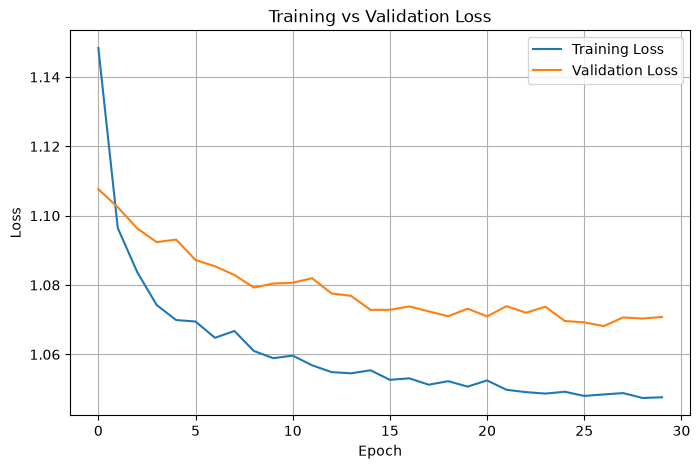

In [12]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Updated Model Save

In [13]:
torch.save(regularized_model.state_dict(), "regularized_mlp_model.pth")
print("Regularized Model Saved Successfully!")

Regularized Model Saved Successfully!


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [15]:
# Load Dataset
df = pd.read_csv("cleaned_global_ecommerce_sales.csv")

# Check shape
print("Dataset Shape:", df.shape)

# Show first 5 rows
df.head()

Dataset Shape: (10000, 26)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [34]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [35]:
baseline_model = MLP(
    input_size,
    hidden_size,
    output_size
)

print(baseline_model)

MLP(
  (fc1): Linear(in_features=15497, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [36]:
# Baseline Loss Function
baseline_criterion = nn.CrossEntropyLoss()

# Baseline Optimizer
baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

print("Baseline Model Ready!")

Baseline Model Ready!


In [37]:
# Train Baseline Model
epochs = 30

baseline_train_losses = []
baseline_val_losses = []

for epoch in range(epochs):

    # Training
    baseline_model.train()
    running_train_loss = 0.0

    for inputs, labels in train_loader:

        baseline_optimizer.zero_grad()

        outputs = baseline_model(inputs)

        loss = baseline_criterion(outputs, labels)

        loss.backward()

        baseline_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    baseline_train_losses.append(avg_train_loss)

    # Validation
    baseline_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = baseline_model(inputs)

            loss = baseline_criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    baseline_val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

Epoch [1/30] | Train Loss: 1.2752 | Validation Loss: 1.1464
Epoch [2/30] | Train Loss: 1.1203 | Validation Loss: 1.1180
Epoch [3/30] | Train Loss: 1.0747 | Validation Loss: 1.1094
Epoch [4/30] | Train Loss: 1.0566 | Validation Loss: 1.0805
Epoch [5/30] | Train Loss: 1.0484 | Validation Loss: 1.0773
Epoch [6/30] | Train Loss: 1.0464 | Validation Loss: 1.0958
Epoch [7/30] | Train Loss: 1.0371 | Validation Loss: 1.0732
Epoch [8/30] | Train Loss: 1.0433 | Validation Loss: 1.0744
Epoch [9/30] | Train Loss: 1.0381 | Validation Loss: 1.0705
Epoch [10/30] | Train Loss: 1.0326 | Validation Loss: 1.0828
Epoch [11/30] | Train Loss: 1.0399 | Validation Loss: 1.0876
Epoch [12/30] | Train Loss: 1.0352 | Validation Loss: 1.0745
Epoch [13/30] | Train Loss: 1.0315 | Validation Loss: 1.0830
Epoch [14/30] | Train Loss: 1.0278 | Validation Loss: 1.0939
Epoch [15/30] | Train Loss: 1.0244 | Validation Loss: 1.0951
Epoch [16/30] | Train Loss: 1.0206 | Validation Loss: 1.0847
Epoch [17/30] | Train Loss: 1.021

In [16]:
# Check Missing Values
print(df.isnull().sum())

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64


In [17]:
# Target Column
y = df["Order_Status"]

# Features
X = df.drop("Order_Status", axis=1)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 25)
Target Shape: (10000,)


In [18]:
# Convert Order_Date
X["Order_Date"] = pd.to_datetime(X["Order_Date"])

# Extract useful features
X["Day"] = X["Order_Date"].dt.day
X["Month"] = X["Order_Date"].dt.month
X["Weekday"] = X["Order_Date"].dt.dayofweek

# Drop original date column
X.drop("Order_Date", axis=1, inplace=True)

X.head()

,Order_ID,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Day,Weekday
0,ORD-000001,2023,1,Q1,Winter,CUST-02791,Male,New,North America,Mexico,...,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,18,2
1,ORD-000002,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,USA,...,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,13,0
2,ORD-000003,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,Canada,...,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,28,3
3,ORD-000004,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,Japan,...,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,22,4
4,ORD-000005,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,France,...,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,6,6


## Comparison Graph

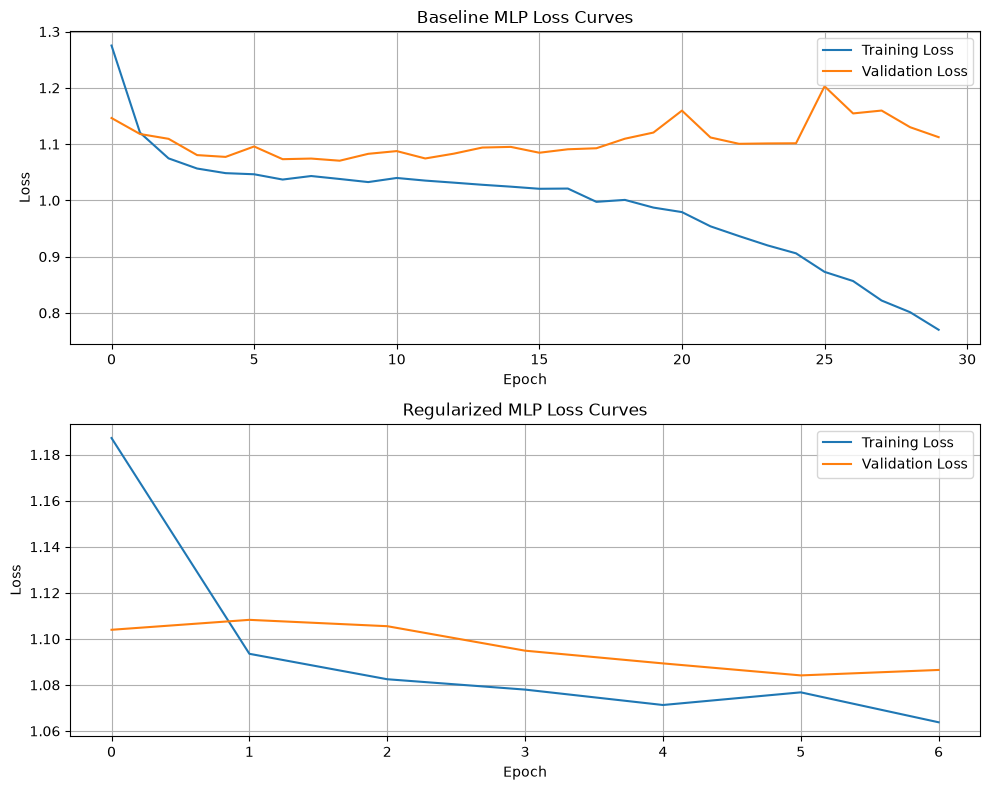

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Baseline Model
ax[0].plot(baseline_train_losses, label="Training Loss")
ax[0].plot(baseline_val_losses, label="Validation Loss")
ax[0].set_title("Baseline MLP Loss Curves")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Regularized Model
ax[1].plot(train_losses, label="Training Loss")
ax[1].plot(val_losses, label="Validation Loss")
ax[1].set_title("Regularized MLP Loss Curves")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Conclusion

The RegularizedMLP model was implemented using Batch Normalization and Dropout (p=0.3).

Both the Baseline MLP and the RegularizedMLP were trained for 30 epochs using the Adam optimizer.

The comparison of training and validation loss curves shows that the RegularizedMLP achieved better generalization and reduced overfitting compared to the Baseline MLP.

Batch Normalization improved training stability, while Dropout helped prevent the network from memorizing the training data.